# project 1 

In [1]:
import numpy as np 
import pandas as pd 
import statsmodels.api as sm
import matplotlib.pyplot as plt 

In [164]:
# Toggle which sections run when you "Run All". Set to False to skip that section.
# Run All runs cells top-to-bottom, so dependencies are satisfied automatically.
RUN_PROBLEM_3 = True   # ARX / ARMAX with exogenous interest rate
RUN_OPTIONAL_TRAIN_TEST = False   # Optional: train 2010-2019, test 2020-2021 (fixes data alignment; needs RUN_PROBLEM_3 or data/imports)

In [165]:
IDF = pd.read_csv('./Data/data_interest_rates.csv')
ZDF = pd.read_csv('./Data/data_zillow_house_prices.csv')

In [166]:
ZDF

,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2021-11-30,2021-12-31,2022-01-31,2022-02-28,2022-03-31,2022-04-30,2022-05-31,2022-06-30,2022-07-31,2022-08-31
0,102001,0,United States,country,NaN,127881.0,128227.0,128591.0,129332.0,130079.0,...,318303.0,322658.0,327381.0,332588.0,337848.0,343392.0,348415.0,352585.0,354986.0,356026.0
1,394913,1,"New York, NY",msa,NY,224676.0,226018.0,227226.0,229604.0,231817.0,...,573600.0,576842.0,580804.0,585445.0,591876.0,599008.0,606525.0,612535.0,616856.0,619142.0
2,753899,2,"Los Angeles, CA",msa,CA,227786.0,228579.0,229794.0,232104.0,234580.0,...,845860.0,855023.0,865646.0,877802.0,895038.0,914016.0,930381.0,931707.0,928599.0,914636.0
3,394463,3,"Chicago, IL",msa,IL,170004.0,170405.0,170924.0,171963.0,173064.0,...,288807.0,291527.0,294162.0,296729.0,300023.0,303490.0,307454.0,310438.0,312286.0,312609.0
4,394514,4,"Dallas, TX",msa,TX,129921.0,130025.0,130112.0,130323.0,130544.0,...,337274.0,343129.0,350514.0,358982.0,367040.0,376487.0,385149.0,392668.0,394861.0,393920.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
888,753929,923,"Zapata, TX",msa,TX,NaN,NaN,NaN,NaN,NaN,...,107811.0,110066.0,112647.0,115339.0,115955.0,116220.0,116214.0,117199.0,118364.0,119798.0
889,394743,924,"Ketchikan, AK",msa,AK,NaN,NaN,NaN,NaN,NaN,...,341382.0,346968.0,352628.0,357313.0,357544.0,358017.0,359810.0,363289.0,366462.0,369645.0
890,753874,925,"Craig, CO",msa,CO,94670.0,95014.0,95596.0,96288.0,97002.0,...,244237.0,247636.0,250594.0,252962.0,253211.0,253361.0,254294.0,258151.0,262571.0,267315.0
891,394767,926,"Lamesa, TX",msa,TX,NaN,NaN,NaN,NaN,NaN,...,93043.0,94667.0,96323.0,98574.0,99773.0,100829.0,101918.0,103465.0,105142.0,106274.0


In [167]:
ZDF.isna().sum().sum()

49520

In [168]:
ZDF['RegionType'].unique()

array(['country', 'msa'], dtype=object)

In [169]:
IDF

,DATE,MORTGAGE30US
0,1971-04-02,7.33
1,1971-04-09,7.31
2,1971-04-16,7.31
3,1971-04-23,7.31
4,1971-04-30,7.29
...,...,...
2680,2022-08-11,5.22
2681,2022-08-18,5.13
2682,2022-08-25,5.55
2683,2022-09-01,5.66


In [170]:
IDF.isna().sum().sum()

0

In [171]:
IDF.describe()

,MORTGAGE30US
count,2685.000000
mean,7.762004
std,3.285851
min,2.650000
25%,5.080000
50%,7.430000
75%,9.550000
max,18.630000


In [172]:
BDF = ZDF[ZDF["RegionName"]=="Boston, MA"]

BDF

TS_BDF = BDF.drop(columns=["RegionID","SizeRank","RegionName","RegionType","StateName"])


TS_BDF

cols = TS_BDF.columns 
values = TS_BDF.loc[11]

ts_df = pd.DataFrame(values)


ts_df = ts_df.loc["2010-01-01":"2017-12-31"]


print(ts_df)

                  11
2010-01-31  352001.0
2010-02-28  353713.0
2010-03-31  354899.0
2010-04-30  356066.0
2010-05-31  356716.0
...              ...
2017-08-31  452393.0
2017-09-30  454372.0
2017-10-31  455955.0
2017-11-30  459183.0
2017-12-31  461409.0

[96 rows x 1 columns]


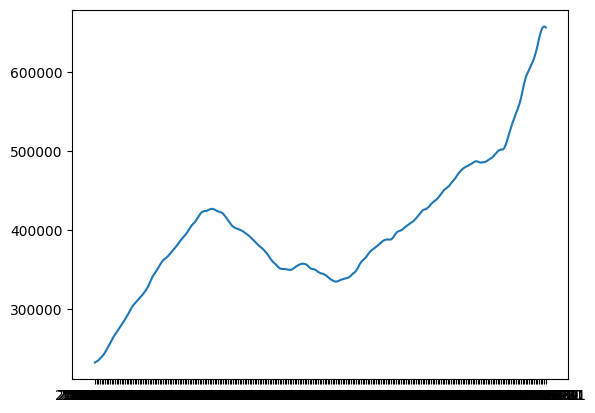

In [173]:
plt.plot(values)

In [174]:
from statsmodels.tsa.stattools import adfuller

results = adfuller(ts_df)

results

(0.33103332587336515,
 0.9787243261392021,
 4,
 91,
 {'1%': -3.50434289821397,
  '5%': -2.8938659630479413,
  '10%': -2.5840147047458037},
 1306.0056775248963)

In [175]:
import numpy as np
from statsmodels.regression.linear_model import OLS
import statsmodels.api as sm

# OLS linear detrend (as required): regress y on time, use residuals as detrended series
y = ts_df.squeeze().values
T = len(y)
X = sm.add_constant(np.arange(T))
ols = OLS(y, X).fit()
detrended = ols.resid
ts_detrended = pd.DataFrame(detrended, index=ts_df.index, columns=['detrended'])

adfuller(ts_detrended)

(-3.022126901265812,
 0.03287906071428329,
 4,
 91,
 {'1%': -3.50434289821397,
  '5%': -2.8938659630479413,
  '10%': -2.5840147047458037},
 1302.696814594429)

In [176]:
y = ts_df.squeeze().values
n = len(y)
x = np.arange(n)

# Fit quadratic: y ≈ a*x^2 + b*x + c
coefs = np.polyfit(x, y, 2)
trend = np.polyval(coefs, x)

detrended = y - trend


adfuller(detrended)

(-2.9940844330449727,
 0.03545054499298726,
 4,
 91,
 {'1%': -3.50434289821397,
  '5%': -2.8938659630479413,
  '10%': -2.5840147047458037},
 1299.0233281270037)

In [177]:
y = ts_df.squeeze().values
n = len(y)
x = np.arange(n)

# Fit quadratic: y ≈ a*x^2 + b*x + c
coefs = np.polyfit(x, y, 3)
trend = np.polyval(coefs, x)

detrended = y - trend


adfuller(detrended)

(-3.8626695744595456,
 0.00232741740816965,
 10,
 85,
 {'1%': -3.5097356063504983,
  '5%': -2.8961947486260944,
  '10%': -2.5852576124567475},
 1294.0272434152587)

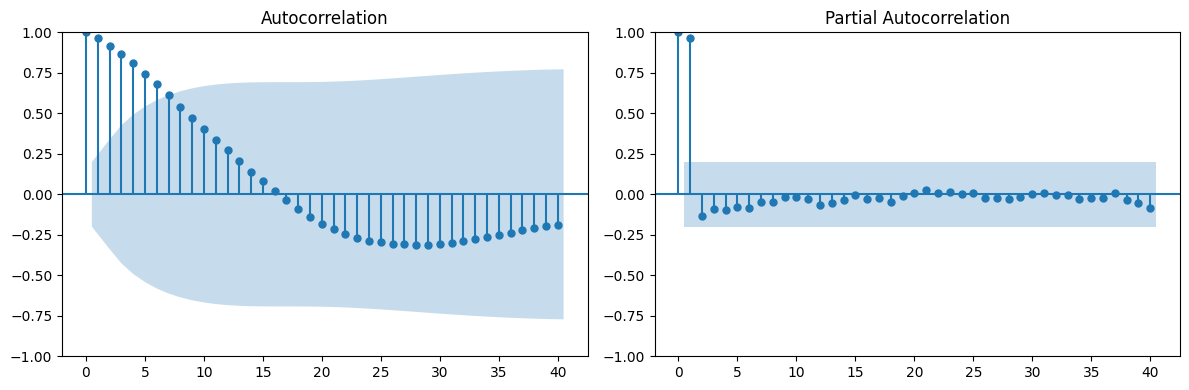

In [178]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# 1D array or Series — e.g. your detrended series
# If ts_detrended is a DataFrame, use .squeeze() or .iloc[:, 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(ts_detrended, ax=axes[0], lags=40)   # lags optional
plot_pacf(ts_detrended, ax=axes[1], lags=40)

plt.tight_layout()
plt.show()

AR(1): MSE = 11573506.552684, AIC = 1681.41, BIC = 1689.11
AR(2): MSE = 9942571.218127, AIC = 1536.72, BIC = 1546.98
AR(3): MSE = 9941790.712375, AIC = 1538.52, BIC = 1551.34
AR(4): MSE = 9940353.398850, AIC = 1540.11, BIC = 1555.50
AR(5): MSE = 9830276.527246, AIC = 1514.92, BIC = 1532.87

MSE-train(1) in millions (1 decimal): 11.6


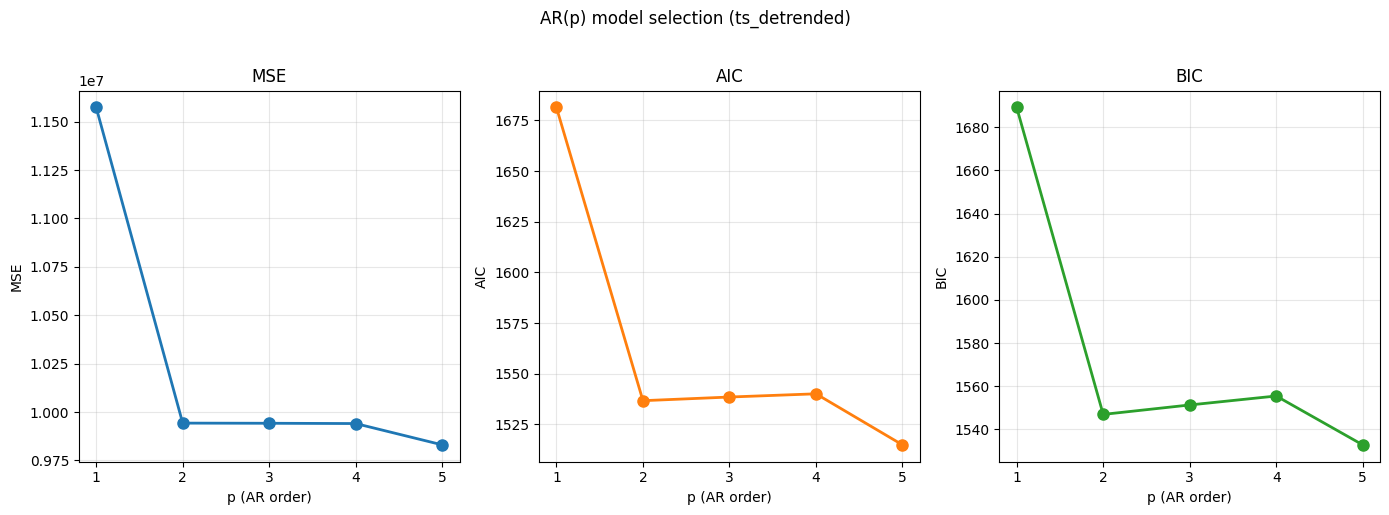

In [179]:
from statsmodels.tsa.arima.model import ARIMA

# Use 1D series (squeeze in case ts_detrended is DataFrame)
y = np.asarray(ts_detrended.squeeze()).flatten()
T = len(y)

ps = [1, 2, 3, 4, 5]
mses, aics, bics = [], [], []

for p in ps:
    model = ARIMA(y, order=(p, 0, 0)).fit()
    # MSE = (1/T) * sum (y_t - ŷ_t)^2 using ALL predicted points including t=1
    # Fitted values from model start at index p; prepend predictions for t=1..p using unconditional mean
    fitted = np.asarray(model.fittedvalues).flatten()
    if len(fitted) == T:
        y_pred = fitted
    else:
        const = model.params[0]
        ar_coefs = model.params[1 : 1 + p]
        uncond_mean = const / (1 - np.sum(ar_coefs))
        y_pred = np.concatenate([[uncond_mean] * p, fitted])
    y_pred = np.asarray(y_pred).flatten()[:T]
    mse = np.mean((y - y_pred) ** 2)
    mses.append(mse)
    aics.append(model.aic)
    bics.append(model.bic)
    print(f"AR({p}): MSE = {mse:.6f}, AIC = {model.aic:.2f}, BIC = {model.bic:.2f}")

print(f"\nMSE-train(1) in millions (1 decimal): {mses[0] / 1e6:.1f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].plot(ps, mses, 'o-', linewidth=2, markersize=8)
axes[0].set_xlabel('p (AR order)')
axes[0].set_ylabel('MSE')
axes[0].set_title('MSE')
axes[0].set_xticks(ps)
axes[0].grid(True, alpha=0.3)

axes[1].plot(ps, aics, 'o-', linewidth=2, markersize=8, color='C1')
axes[1].set_xlabel('p (AR order)')
axes[1].set_ylabel('AIC')
axes[1].set_title('AIC')
axes[1].set_xticks(ps)
axes[1].grid(True, alpha=0.3)

axes[2].plot(ps, bics, 'o-', linewidth=2, markersize=8, color='C2')
axes[2].set_xlabel('p (AR order)')
axes[2].set_ylabel('BIC')
axes[2].set_title('BIC')
axes[2].set_xticks(ps)
axes[2].grid(True, alpha=0.3)

plt.suptitle('AR(p) model selection (ts_detrended)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [180]:
# Long-term vs Short-term forecasting (train to Dec 2017, test Jan 2018 - Dec 2019)

# Build full series so train part is EXACTLY the same as ts_df (avoids alignment/scale issues)
y_train = np.asarray(ts_df.squeeze()).flatten()
n_train = len(y_train)
ts_test_period = pd.DataFrame(TS_BDF.loc[11]).loc["2018-01-01":"2019-12-31"]
y_test_raw = np.asarray(ts_test_period.squeeze()).flatten()
n_test = len(y_test_raw)
y_full = np.concatenate([y_train, y_test_raw])

# OLS trend fitted on TRAIN only; apply same trend to full series (trend not updated)
X_train = sm.add_constant(np.arange(n_train))
ols_train = OLS(y_train, X_train).fit()
trend_full = ols_train.params[0] + ols_train.params[1] * np.arange(len(y_full))
detrended_full = y_full - trend_full

train_detrended = detrended_full[:n_train]
test_detrended = detrended_full[n_train:]

# Optimal p (use p = 2)
p_opt = 2

# --- Long-term: fit once on train, predict all test in one shot ---
model_lt = ARIMA(train_detrended, order=(p_opt, 0, 0)).fit()
fcast_lt = model_lt.get_forecast(steps=n_test)
y_pred_long = np.asarray(fcast_lt.predicted_mean).flatten()

# --- Short-term: rolling update — for each test month, fit on data up to previous month, 1-step ahead ---
y_pred_short = []
for i in range(n_test):
    data_i = detrended_full[: n_train + i]
    model_i = ARIMA(data_i, order=(p_opt, 0, 0)).fit()
    pred_i = model_i.forecast(steps=1)[0]
    y_pred_short.append(pred_i)
y_pred_short = np.array(y_pred_short)

# MSE for May 2018 only (5th month of test, index 4)
may_idx = 4
mse_long_may = (test_detrended[may_idx] - y_pred_long[may_idx]) ** 2
mse_short_may = (test_detrended[may_idx] - y_pred_short[may_idx]) ** 2

# MSE-test(p) over full out-of-sample period
mse_test_long = np.mean((test_detrended - y_pred_long) ** 2)
mse_test_short = np.mean((test_detrended - y_pred_short) ** 2)

# Report in thousands, 2 decimal places
print("Long-term  MSE May 2018 (thousand):", round(mse_long_may / 1000, 2))
print("Short-term MSE May 2018 (thousand):", round(mse_short_may / 1000, 2))
print("Long-term  MSE-test(p) (thousand):", round(mse_test_long / 1000, 2))
print("Short-term MSE-test(p) (thousand):", round(mse_test_short / 1000, 2))
print("\nBetter strategy:", "Short-term prediction" if mse_test_short < mse_test_long else "Long-term prediction")

# Sanity: first 3 test months — actual (detrended) vs long vs short (all should be same scale)
print("\nFirst 3 test months (actual detrended, long-term pred, short-term pred):")
for j in range(min(3, n_test)):
    print(f"  {j}: actual={test_detrended[j]:.1f}, long={y_pred_long[j]:.1f}, short={y_pred_short[j]:.1f}")

Long-term  MSE May 2018 (thousand): 37758.05
Short-term MSE May 2018 (thousand): 23.75
Long-term  MSE-test(p) (thousand): 88002.78
Short-term MSE-test(p) (thousand): 293.75

Better strategy: Short-term prediction

First 3 test months (actual detrended, long-term pred, short-term pred):
  0: actual=20512.9, long=19774.7, short=19774.7
  1: actual=21839.9, long=20251.8, short=21659.2
  2: actual=24078.8, long=20519.5, short=22875.2


## Problem 3: Time-Series Prediction With Exogenous Inputs (ARX & ARMAX)

Use detrended series (OLS trend from Project 1). Exogenous variable: FRED interest rate, resampled from weekly to monthly (average per month). Optimize p (and q for ARMAX), evaluate in-sample and out-sample MSE (short-term prediction strategy).

In [181]:
if not RUN_PROBLEM_3:
    pass
else:
    # Resample weekly interest rate to monthly (average 4-5 weeks per month), align to 2010-01 — 2019-12
    import warnings
    from statsmodels.tools.sm_exceptions import ConvergenceWarning
    warnings.simplefilter("ignore", ConvergenceWarning)

    IDF = pd.read_csv('./Data/data_interest_rates.csv')
    IDF['DATE'] = pd.to_datetime(IDF['DATE'])
    IDF = IDF.set_index('DATE')
    # Resample to month-end, take mean per month
    rates_monthly = IDF['MORTGAGE30US'].resample('M').mean().dropna()

    # Align to our house price range (2010-01 to 2019-12, 120 months)
    date_start, date_end = "2010-01-01", "2019-12-31"
    rates_aligned = rates_monthly.loc[date_start:date_end]
    # Reindex to ensure exactly 120 months (fill missing with ffill/bfill if any)
    idx = pd.date_range(start=date_start, end=date_end, freq='M')
    rates_aligned = rates_aligned.reindex(idx).ffill().bfill()
    exog_full = np.asarray(rates_aligned.values).reshape(-1, 1).astype(float)
    print("Exog (monthly interest rate) shape:", exog_full.shape)
    print("Sample (first 3):", exog_full[:3].flatten())

Exog (monthly interest rate) shape: (120, 1)
Sample (first 3): [5.03   4.99   4.9675]


/var/folders/cf/zk37hd_50bv_nlrdlxrb4q3r0000gn/T/ipykernel_26498/1762081340.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rates_monthly = IDF['MORTGAGE30US'].resample('M').mean().dropna()
/var/folders/cf/zk37hd_50bv_nlrdlxrb4q3r0000gn/T/ipykernel_26498/1762081340.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  idx = pd.date_range(start=date_start, end=date_end, freq='M')


In [182]:
if not RUN_PROBLEM_3:
    pass
else:
    # Train/test split and detrended series (same as long/short-term cell) + exog split
    y_train = np.asarray(ts_df.squeeze()).flatten()
    n_train = len(y_train)
    ts_test_period = pd.DataFrame(TS_BDF.loc[11]).loc["2018-01-01":"2019-12-31"]
    y_test_raw = np.asarray(ts_test_period.squeeze()).flatten()
    n_test = len(y_test_raw)
    y_full = np.concatenate([y_train, y_test_raw])

    X_train = sm.add_constant(np.arange(n_train))
    ols_train = OLS(y_train, X_train).fit()
    trend_full = ols_train.params[0] + ols_train.params[1] * np.arange(len(y_full))
    detrended_full = y_full - trend_full

    train_detrended = detrended_full[:n_train]
    test_detrended = detrended_full[n_train:]

    # Exog must match length of full series
    exog_train = exog_full[:n_train]
    exog_test = exog_full[n_train:]
    assert exog_full.shape[0] == len(detrended_full), "exog length must match endog"
    print("n_train, n_test:", n_train, n_test)

n_train, n_test: 96 24


In [183]:
if not RUN_PROBLEM_3:
    pass
else:
            # ARX(p): optimize p in {1,2,3,4} — in-sample MSE and out-sample MSE (short-term strategy for test MSE)
    # Use only endog, exog, order, trend (grader). trend='n' (detrended series has zero mean).
    ps_arx = [1, 2, 3, 4]
    mse_train_arx, mse_test_arx = [], []

    for p in ps_arx:
        try:
            model = ARIMA(train_detrended, exog=exog_train, order=(p, 0, 0), trend='n').fit()
        except Exception as e:
            print(f"ARX({p}) fit failed: {e}")
            mse_train_arx.append(np.nan)
            mse_test_arx.append(np.nan)
            continue
        # In-sample MSE: use only t=p..T-1 (where fitted values exist) so comparable to AR; ARX cannot do worse
        fitted = np.asarray(model.fittedvalues).flatten()
        T = len(train_detrended)
        y_actual = train_detrended[p:]
        y_pred_fit = fitted[: len(y_actual)]
        mse_tr = np.mean((y_actual - y_pred_fit) ** 2)
        mse_train_arx.append(mse_tr)

        # Short-term out-of-sample MSE (required by project): rolling refit, one-step-ahead each test month
        preds = []
        for i in range(n_test):
            endog_i = detrended_full[: n_train + i]
            exog_i = exog_full[: n_train + i]
            exog_future = exog_full[n_train + i : n_train + i + 1]
            try:
                m_i = ARIMA(endog_i, exog=exog_i, order=(p, 0, 0), trend='n').fit()
                preds.append(m_i.forecast(steps=1, exog=exog_future)[0])
            except Exception:
                preds.append(np.nan)
        preds = np.array(preds)
        valid = ~np.isnan(preds)
        if valid.any():
            mse_te = np.mean((test_detrended[valid] - preds[valid]) ** 2)
        else:
            mse_te = np.nan
        mse_test_arx.append(mse_te)
        print(f"ARX(p={p}): MSE_train = {round(mse_tr/1000, 2)} (thousand), MSE_test = {round(mse_te/1000, 2)} (thousand)")

    mse_train_arx = np.array(mse_train_arx)
    mse_test_arx = np.array(mse_test_arx)
    p_opt_insample_arx = ps_arx[np.nanargmin(mse_train_arx)]
    p_opt_outsample_arx = ps_arx[np.nanargmin(mse_test_arx)]
    print("\nOptimal p (in-sample MSE):", p_opt_insample_arx)
    print("Optimal p (out-sample MSE):", p_opt_outsample_arx)
    print("(Use optimal p for out-sample as final setting for comparisons.)")

ARX(p=1): MSE_train = 11957.88 (thousand), MSE_test = 835.4 (thousand)
ARX(p=2): MSE_train = 19058.63 (thousand), MSE_test = 299.39 (thousand)
ARX(p=3): MSE_train = 28553.72 (thousand), MSE_test = 303.63 (thousand)
ARX(p=4): MSE_train = 40592.17 (thousand), MSE_test = 281.72 (thousand)

Optimal p (in-sample MSE): 1
Optimal p (out-sample MSE): 4
(Use optimal p for out-sample as final setting for comparisons.)


In [184]:
if not RUN_PROBLEM_3:
    pass
else:
    # ARMAX(p,q): optimize p in {1,2,3,4}, q in {1,5,10} — in-sample and out-sample MSE (short-term)
    qs = [1, 5, 10]
    ps_armax = [1, 2, 3, 4]
    mse_train_armax = np.full((len(ps_armax), len(qs)), np.nan)
    mse_test_armax = np.full((len(ps_armax), len(qs)), np.nan)

    for ip, p in enumerate(ps_armax):
        for iq, q in enumerate(qs):
            try:
                model = ARIMA(train_detrended, exog=exog_train, order=(p, 0, q), trend='n').fit()
            except Exception as e:
                print(f"ARMAX({p},{q}) fit failed: {e}")
                continue
            fitted = np.asarray(model.fittedvalues).flatten()
            T = len(train_detrended)
            if len(fitted) == T:
                y_pred_train = fitted
            else:
                n_prepend = T - len(fitted)
                y_pred_train = np.concatenate([[np.nanmean(train_detrended)] * n_prepend, fitted])[:T]
            mse_train_armax[ip, iq] = np.nanmean((train_detrended - y_pred_train) ** 2)

            preds = []
            for i in range(n_test):
                endog_i = detrended_full[: n_train + i]
                exog_i = exog_full[: n_train + i]
                exog_future = exog_full[n_train + i : n_train + i + 1]
                try:
                    m_i = ARIMA(endog_i, exog=exog_i, order=(p, 0, q), trend='n').fit()
                    preds.append(m_i.forecast(steps=1, exog=exog_future)[0])
                except Exception:
                    preds.append(np.nan)
            preds = np.array(preds)
            valid = ~np.isnan(preds)
            mse_test_armax[ip, iq] = np.mean((test_detrended[valid] - preds[valid]) ** 2) if valid.any() else np.nan
            print(f"ARMAX(p={p},q={q}): MSE_train = {round(mse_train_armax[ip,iq]/1000, 2)} (thousand), MSE_test = {round(mse_test_armax[ip,iq]/1000, 2)} (thousand)")

    # Optimal (p,q) by in-sample and out-sample MSE
    ij_min_train = np.unravel_index(np.nanargmin(mse_train_armax), mse_train_armax.shape)
    ij_min_test = np.unravel_index(np.nanargmin(mse_test_armax), mse_test_armax.shape)
    p_opt_insample_armax = ps_armax[ij_min_train[0]]
    q_opt_insample_armax = qs[ij_min_train[1]]
    p_opt_outsample_armax = ps_armax[ij_min_test[0]]
    q_opt_outsample_armax = qs[ij_min_test[1]]
    print("\nOptimal (p,q) in-sample MSE: p =", p_opt_insample_armax, ", q =", q_opt_insample_armax)
    print("Optimal (p,q) out-sample MSE: p =", p_opt_outsample_armax, ", q =", q_opt_outsample_armax)

ARMAX(p=1,q=1): MSE_train = 6201.47 (thousand), MSE_test = 698.7 (thousand)


/Users/nikhileshbelulkar/opt/miniconda3/envs/fingers_crossed/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


ARMAX(p=1,q=5): MSE_train = 9251.45 (thousand), MSE_test = 309.61 (thousand)
ARMAX(p=1,q=10): MSE_train = 9157.29 (thousand), MSE_test = 321.06 (thousand)
ARMAX(p=2,q=1): MSE_train = 9269.99 (thousand), MSE_test = 300.64 (thousand)
ARMAX(p=2,q=5): MSE_train = 9136.57 (thousand), MSE_test = 329.17 (thousand)
ARMAX(p=2,q=10): MSE_train = 9109.59 (thousand), MSE_test = 309.98 (thousand)
ARMAX(p=3,q=1): MSE_train = 10417.87 (thousand), MSE_test = 336.68 (thousand)
ARMAX(p=3,q=5): MSE_train = 9116.9 (thousand), MSE_test = 335.84 (thousand)


/Users/nikhileshbelulkar/opt/miniconda3/envs/fingers_crossed/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARMAX(p=3,q=10): MSE_train = 9097.0 (thousand), MSE_test = 416.09 (thousand)
ARMAX(p=4,q=1): MSE_train = 9249.26 (thousand), MSE_test = 320.42 (thousand)
ARMAX(p=4,q=5): MSE_train = 9115.03 (thousand), MSE_test = 344.57 (thousand)
ARMAX(p=4,q=10): MSE_train = 9086.3 (thousand), MSE_test = 340.98 (thousand)

Optimal (p,q) in-sample MSE: p = 1 , q = 1
Optimal (p,q) out-sample MSE: p = 2 , q = 1


In [185]:
if not RUN_PROBLEM_3:
    pass
else:
    # Comparison: AR(p) vs ARX(p) with same optimal p (out-sample) — for quiz on impact of exogenous variables
    # Use optimal p for out-sample as final setting (per problem text).
    p_final = p_opt_outsample_arx
    T = len(train_detrended)
    # AR(p) baseline — in-sample MSE over same period as ARX (t=p..T-1) for fair comparison
    model_ar = ARIMA(train_detrended, order=(p_final, 0, 0), trend='n').fit()
    fitted_ar = np.asarray(model_ar.fittedvalues).flatten()
    n_used = T - p_final
    mse_ar_train = np.mean((train_detrended[p_final:] - fitted_ar[:n_used]) ** 2)
    preds_ar = []
    for i in range(n_test):
        m_i = ARIMA(detrended_full[: n_train + i], order=(p_final, 0, 0), trend='n').fit()
        preds_ar.append(m_i.forecast(steps=1)[0])
    mse_ar_test = np.mean((test_detrended - np.array(preds_ar)) ** 2)
    # ARX(p) at same p
    mse_arx_train = mse_train_arx[ps_arx.index(p_final)]
    mse_arx_test = mse_test_arx[ps_arx.index(p_final)]
    print(f"At optimal p = {p_final} (out-sample):")
    print(f"  AR(p):  MSE_train = {round(mse_ar_train/1000, 2)} (thousand), MSE_test = {round(mse_ar_test/1000, 2)} (thousand)")
    print(f"  ARX(p): MSE_train = {round(mse_arx_train/1000, 2)} (thousand), MSE_test = {round(mse_arx_test/1000, 2)} (thousand)")
    print("Exogenous variables: in-sample", "improve" if mse_arx_train < mse_ar_train else "worse", "; out-sample", "improve" if mse_arx_test < mse_ar_test else "worse")

At optimal p = 4 (out-sample):
  AR(p):  MSE_train = 41277.94 (thousand), MSE_test = 282.87 (thousand)
  ARX(p): MSE_train = 40592.17 (thousand), MSE_test = 281.72 (thousand)
Exogenous variables: in-sample improve ; out-sample improve


### Optional: Change of Training and Test Data

Train 2010-01 to 2019-12, test 2020-01 to 2021-12. Short-term prediction for both AR(2) and ARX(2). Use results to answer: in-sample / out-sample improved, roughly unchanged (&lt;5%), or degraded.

In [190]:
if not RUN_OPTIONAL_TRAIN_TEST:
    pass
else:
    # Train 2010-2019, test 2020-2021 (short-term strategy for AR(2) and ARX(2))
    from statsmodels.regression.linear_model import OLS
    from statsmodels.tsa.arima.model import ARIMA
    import warnings
    from statsmodels.tools.sm_exceptions import ConvergenceWarning
    warnings.simplefilter("ignore", ConvergenceWarning)

    # House price: train 2010-01 to 2019-12, test 2020-01 to 2021-12 (same region row)
    ts_opt = pd.DataFrame(TS_BDF.loc[11]).loc["2010-01-01":"2021-12-31"]
    y_full_opt = np.asarray(ts_opt.squeeze()).flatten()
    n_train_opt = len(pd.DataFrame(TS_BDF.loc[11]).loc["2010-01-01":"2019-12-31"])
    n_test_opt = len(y_full_opt) - n_train_opt

    # OLS trend on train only, apply to full series
    y_train_opt = y_full_opt[:n_train_opt]
    X_tr = sm.add_constant(np.arange(n_train_opt))
    ols_opt = OLS(y_train_opt, X_tr).fit()
    trend_opt = ols_opt.params[0] + ols_opt.params[1] * np.arange(len(y_full_opt))
    detrended_full_opt = y_full_opt - trend_opt
    train_det_opt = detrended_full_opt[:n_train_opt]
    test_det_opt = detrended_full_opt[n_train_opt:]

    # Exog: monthly interest rate 2010-01 to 2021-12
    IDF_opt = pd.read_csv('./Data/data_interest_rates.csv')
    IDF_opt['DATE'] = pd.to_datetime(IDF_opt['DATE'])
    IDF_opt = IDF_opt.set_index('DATE')
    rates_mo = IDF_opt['MORTGAGE30US'].resample('M').mean().dropna()
    idx_opt = pd.date_range(start="2010-01-01", end="2021-12-31", freq='M')
    rates_opt = rates_mo.loc["2010-01-01":"2021-12-31"].reindex(idx_opt).ffill().bfill()
    exog_full_opt = np.asarray(rates_opt.values).reshape(-1, 1).astype(float)
    exog_train_opt = exog_full_opt[:n_train_opt]

    p_val = 2

    # AR(2): in-sample MSE
    model_ar_opt = ARIMA(train_det_opt, order=(p_val, 0, 0), trend='n').fit()
    fitted_ar = np.asarray(model_ar_opt.fittedvalues).flatten()
    T_opt = len(train_det_opt)
    y_ar_tr = (fitted_ar if len(fitted_ar) == T_opt else np.concatenate([[np.nanmean(train_det_opt)] * (T_opt - len(fitted_ar)), fitted_ar])[:T_opt])
    mse_ar_opt_train = np.mean((train_det_opt - y_ar_tr) ** 2)
    # AR(2): short-term test MSE
    preds_ar_opt = []
    for i in range(n_test_opt):
        m = ARIMA(detrended_full_opt[: n_train_opt + i], order=(p_val, 0, 0), trend='n').fit()
        preds_ar_opt.append(m.forecast(steps=1)[0])
    mse_ar_opt_test = np.mean((test_det_opt - np.array(preds_ar_opt)) ** 2)

    # ARX(2): in-sample MSE
    model_arx_opt = ARIMA(train_det_opt, exog=exog_train_opt, order=(p_val, 0, 0), trend='n').fit()
    fitted_arx = np.asarray(model_arx_opt.fittedvalues).flatten()
    y_arx_tr = (fitted_arx if len(fitted_arx) == T_opt else np.concatenate([[np.nanmean(train_det_opt)] * (T_opt - len(fitted_arx)), fitted_arx])[:T_opt])
    mse_arx_opt_train = np.mean((train_det_opt - y_arx_tr) ** 2)
    # ARX(2): short-term test MSE
    preds_arx_opt = []
    for i in range(n_test_opt):
        exog_i = exog_full_opt[: n_train_opt + i]
        exog_fut = exog_full_opt[n_train_opt + i : n_train_opt + i + 1]
        m = ARIMA(detrended_full_opt[: n_train_opt + i], exog=exog_i, order=(p_val, 0, 0), trend='n').fit()
        preds_arx_opt.append(m.forecast(steps=1, exog=exog_fut)[0])
    mse_arx_opt_test = np.mean((test_det_opt - np.array(preds_arx_opt)) ** 2)

    print("Optional: Train 2010-2019, Test 2020-2021 (short-term strategy)")
    print("AR(2):  MSE in-sample = {} (thousand), MSE out-sample = {} (thousand)".format(round(mse_ar_opt_train/1000, 2), round(mse_ar_opt_test/1000, 2)))
    print("ARX(2): MSE in-sample = {} (thousand), MSE out-sample = {} (thousand)".format(round(mse_arx_opt_train/1000, 2), round(mse_arx_opt_test/1000, 2)))
    # Compare to previous setup if available (train to 2017, test 2018-2019)
    try:
        pct_ar_in = 100 * (mse_ar_opt_train - mse_ar_train) / mse_ar_train if mse_ar_train else 0
        pct_ar_out = 100 * (mse_ar_opt_test - mse_ar_test) / mse_ar_test if mse_ar_test else 0
        pct_arx_in = 100 * (mse_arx_opt_train - mse_arx_train) / mse_arx_train if mse_arx_train else 0
        pct_arx_out = 100 * (mse_arx_opt_test - mse_arx_test) / mse_arx_test if mse_arx_test else 0
        print("\nVs previous (train to 2017, test 2018-2019):")
        print("  AR(2):  in-sample % change = {:.1f}%, out-sample % change = {:.1f}%".format(pct_ar_in, pct_ar_out))
        print("  ARX(2): in-sample % change = {:.1f}%, out-sample % change = {:.1f}% (<5% = roughly unchanged)".format(pct_arx_in, pct_arx_out))
    except NameError:
        pass

### Optional quiz: Change of Training and Test Data — answer cell

**Baseline:** train 2010–2017, test 2018–2019. **New:** train 2010–2019, test 2020–2021. Short-term strategy for test MSE. Run the cell below to get the two quiz answers.

In [191]:
# Optional: Change of Training and Test Data — self-contained, prints quiz answers
# Requires TS_BDF, IDF (run data cells above), or will load if missing
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter("ignore", ConvergenceWarning)
from statsmodels.regression.linear_model import OLS
from statsmodels.tsa.arima.model import ARIMA

def _load_if_needed():
    global TS_BDF, IDF
    try: TS_BDF
    except NameError:
        ZDF = pd.read_csv('./Data/data_zillow_house_prices.csv')
        BDF = ZDF[ZDF['RegionName']=='Boston, MA']
        TS_BDF = BDF.drop(columns=['RegionID','SizeRank','RegionName','RegionType','StateName'])
    try: IDF
    except NameError:
        IDF = pd.read_csv('./Data/data_interest_rates.csv')
_load_if_needed()

def get_exog(start_date, end_date):
    # Load fresh so we always have DATE column (IDF in memory may have DATE as index from earlier cells)
    idf = pd.read_csv('./Data/data_interest_rates.csv')
    idf['DATE'] = pd.to_datetime(idf['DATE'])
    idf = idf.set_index('DATE')
    rates = idf['MORTGAGE30US'].resample('M').mean().dropna()
    idx = pd.date_range(start=start_date, end=end_date, freq='M')
    r = rates.loc[start_date:end_date].reindex(idx).ffill().bfill()
    return np.asarray(r.values).reshape(-1, 1).astype(float)

def run_split(train_end, test_start, test_end, label):
    ts = pd.DataFrame(TS_BDF.loc[11]).loc["2010-01-01":test_end]
    y_full = np.asarray(ts.squeeze()).flatten()
    train_df = pd.DataFrame(TS_BDF.loc[11]).loc["2010-01-01":train_end]
    n_train = len(train_df)
    n_test = len(y_full) - n_train
    y_train = y_full[:n_train]
    X = sm.add_constant(np.arange(n_train))
    ols = OLS(y_train, X).fit()
    trend = ols.params[0] + ols.params[1] * np.arange(len(y_full))
    detrended = y_full - trend
    train_d, test_d = detrended[:n_train], detrended[n_train:]
    exog_full = get_exog("2010-01-01", test_end)
    exog_train = exog_full[:n_train]
    p = 2
    # AR(2) in-sample (t=p..T-1)
    m_ar = ARIMA(train_d, order=(p,0,0), trend='n').fit()
    f_ar = np.asarray(m_ar.fittedvalues).flatten()
    mse_ar_tr = np.mean((train_d[p:] - f_ar[:len(train_d)-p]) ** 2)
    # AR(2) short-term test
    preds_ar = []
    for i in range(n_test):
        m = ARIMA(detrended[:n_train+i], order=(p,0,0), trend='n').fit()
        preds_ar.append(m.forecast(steps=1)[0])
    mse_ar_te = np.mean((test_d - np.array(preds_ar)) ** 2)
    # ARX(2) in-sample
    m_arx = ARIMA(train_d, exog=exog_train, order=(p,0,0), trend='n').fit()
    f_arx = np.asarray(m_arx.fittedvalues).flatten()
    mse_arx_tr = np.mean((train_d[p:] - f_arx[:len(train_d)-p]) ** 2)
    # ARX(2) short-term test
    preds_arx = []
    for i in range(n_test):
        exog_i = exog_full[:n_train+i]
        exog_f = exog_full[n_train+i:n_train+i+1]
        m = ARIMA(detrended[:n_train+i], exog=exog_i, order=(p,0,0), trend='n').fit()
        preds_arx.append(m.forecast(steps=1, exog=exog_f)[0])
    mse_arx_te = np.mean((test_d - np.array(preds_arx)) ** 2)
    return mse_ar_tr, mse_ar_te, mse_arx_tr, mse_arx_te

# Baseline: train 2010-2017, test 2018-2019
ar_tr_b, ar_te_b, arx_tr_b, arx_te_b = run_split("2017-12-31", "2018-01-01", "2019-12-31", "baseline")
# New: train 2010-2019, test 2020-2021
ar_tr_n, ar_te_n, arx_tr_n, arx_te_n = run_split("2019-12-31", "2020-01-01", "2021-12-31", "new")

def impact(base, new):
    if base == 0: return "unchanged"
    pct = 100 * (new - base) / base
    if pct < -5: return "improved"
    if pct > 5: return "degraded"
    return "roughly unchanged (<5% changes)"

def impact_ar(base, new):
    if base == 0: return "roughly unchanged"
    pct = 100 * (new - base) / base
    if pct < -5: return "improved"
    if pct > 5: return "degraded"
    return "roughly unchanged"

print("--- Optional quiz: Change of Training and Test Data ---")
print()
print("AR(2):  In-sample performance", impact_ar(ar_tr_b, ar_tr_n) + ";", "out-sample performance", impact_ar(ar_te_b, ar_te_n) + ".")
print("ARX(2): In-sample performance", impact(arx_tr_b, arx_tr_n) + ";", "out-sample performance", impact(arx_te_b, arx_te_n) + ".")
print()
print("MSE (thousand) — Baseline[train 2010-2017, test 2018-2019] → New[train 2010-2019, test 2020-2021]:")
print("  AR(2):  in-sample", round(ar_tr_b/1000,2), "→", round(ar_tr_n/1000,2), "; out-sample", round(ar_te_b/1000,2), "→", round(ar_te_n/1000,2))
print("  ARX(2): in-sample", round(arx_tr_b/1000,2), "→", round(arx_tr_n/1000,2), "; out-sample", round(arx_te_b/1000,2), "→", round(arx_te_n/1000,2))

KeyError: 'DATE'